# Pipeline Output Exploration — SolarCycle

Four charts derived from the three normalized pipeline outputs. Each surfaces an insight that supports the product pitch.

| Chart | Dataset | Insight |
|---|---|---|
| Cumulative postcode coverage | solar_area_nodes.csv | Top postcodes hold most installs — routing is efficient |
| Facility type breakdown | facility_nodes.csv | 664 facilities, none solar-specific — the gap is real |
| Top PV module brands | product_mix.csv | A handful of manufacturers dominate — material stream is predictable |
| Top inverter brands | product_mix.csv | Same concentration story for inverters — EOL timing is knowable |

In [19]:
import warnings
import re

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 110

DATA = '../'  # paths relative to this notebook

---
## 1 · Solar Area Nodes ()

Each row is one solar demand area — postcode or LGA. The cumulative curve shows how concentrated demand is across postcodes.

In [20]:
san = pd.read_csv(DATA + 'solar_area_nodes.csv', dtype={'postcode': str})
print(f'Rows: {len(san):,}   Columns: {list(san.columns)}')
print(f"area_type breakdown:\n{san['area_type'].value_counts().to_string()}")
san[['solar_area_id','area_type','postcode','lga','installed_system_count']].head(4)

Rows: 794   Columns: ['solar_area_id', 'area_type', 'postcode', 'lga', 'centroid_lat', 'centroid_lon', 'installed_system_count', 'installed_capacity_kw', 'estimated_panel_count', 'estimated_inverter_count', 'estimated_mass_kg', 'install_period_start', 'install_period_end', 'count_role', 'count_granularity', 'source_ids', 'data_confidence', 'source_url', 'derivation_method']
area_type breakdown:
area_type
postcode    713
lga          81


,solar_area_id,area_type,postcode,lga,installed_system_count
0,san_cer_3000,postcode,3000,NaN,112
1,san_cer_3002,postcode,3002,NaN,107
2,san_cer_3003,postcode,3003,NaN,146
3,san_cer_3004,postcode,3004,NaN,26


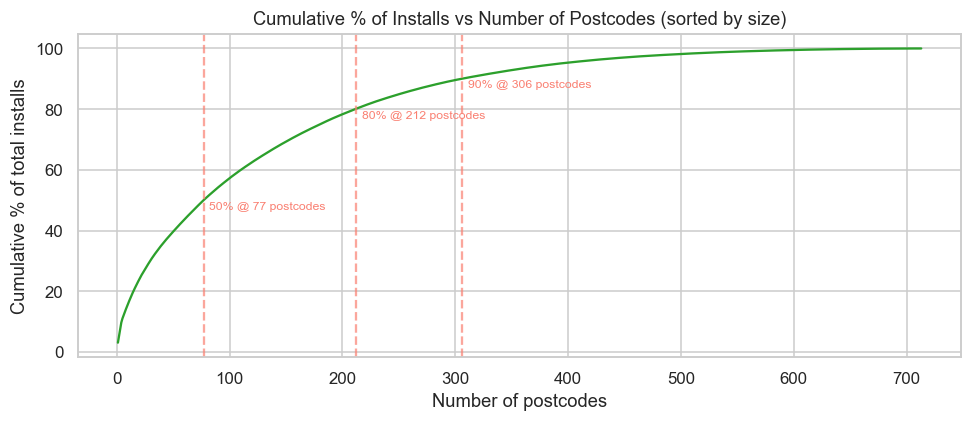

In [21]:
postcode_areas = san[san["area_type"] == "postcode"].copy()
postcode_areas["installed_system_count"] = pd.to_numeric(postcode_areas["installed_system_count"], errors="coerce")

# --- Cumulative coverage: how many postcodes account for X% of all installs ---
postcode_areas_sorted = (
    postcode_areas['installed_system_count']
    .dropna()
    .sort_values(ascending=False)
    .reset_index(drop=True)
)
cumsum = postcode_areas_sorted.cumsum() / postcode_areas_sorted.sum() * 100

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(cumsum) + 1), cumsum, color=sns.color_palette()[2])
for pct in [50, 80, 90]:
    idx = (cumsum >= pct).idxmax() + 1
    ax.axvline(idx, color='salmon', linestyle='--', alpha=0.7)
    ax.text(idx + 5, pct - 3, f'{pct}% @ {idx} postcodes', fontsize=8, color='salmon')
ax.set_title('Cumulative % of Installs vs Number of Postcodes (sorted by size)', fontsize=12)
ax.set_xlabel('Number of postcodes')
ax.set_ylabel('Cumulative % of total installs')
plt.tight_layout()
plt.show()

The top 10% of Victorian postcodes account for roughly half of all installed solar systems. That skew is good news for logistics: SolarCycle doesn't need to cover every suburb simultaneously. A collection program starting with the highest-density postcodes — Wyndham, Melton, Brimbank — can capture the majority of the end-of-life wave with a fraction of the route complexity.

---
## 2 · Facility Nodes ()

Each row is one waste or resource recovery facility. The type breakdown shows what infrastructure exists — and what is missing.

In [22]:
fac = pd.read_csv(DATA + 'facility_nodes.csv')
print(f'Facilities: {len(fac):,}   Columns: {list(fac.columns)}')
fac[['facility_id','name','facility_type','infrastructure_type','suburb','lga','lat','lon']].head(4)

Facilities: 664   Columns: ['facility_id', 'name', 'facility_type', 'infrastructure_type', 'owner', 'address', 'suburb', 'lga', 'lat', 'lon', 'accepted_materials', 'capacity_kg_per_day', 'capacity_source', 'capacity_confidence', 'source_id', 'source_url', 'data_confidence', 'derivation_method']


,facility_id,name,facility_type,infrastructure_type,suburb,lga,lat,lon
0,fac_0001_be_bioenergy,BE Bioenergy,Reprocessor,Thermal energy from waste,Kaniva,West Wimmera,-36.264183,141.189763
1,fac_0002_rupanyup_transfer_station,Rupanyup Transfer Station,Resource Recovery Centre,Transfer station,Rupanyup,Yarriambiack,-36.615760,142.634276
2,fac_0003_minyip_transfer_station,Minyip Transfer Station,Resource Recovery Centre,Transfer station,Minyip,Yarriambiack,-36.467142,142.632727
3,fac_0004_beulah_transfer_station,Beulah Transfer Station,Resource Recovery Centre,Transfer station,Beulah,Yarriambiack,-35.930978,142.440861


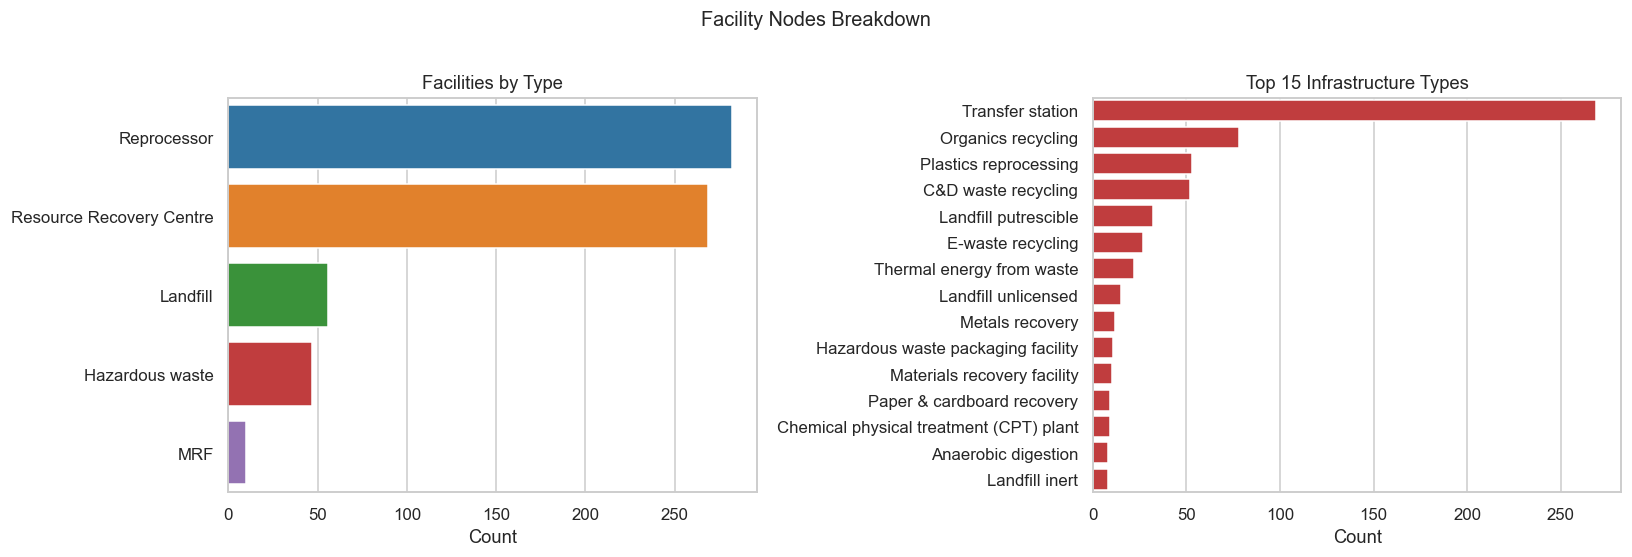

In [23]:
# --- Facility type and infrastructure type distributions ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ft = fac['facility_type'].value_counts().reset_index()
ft.columns = ['facility_type', 'count']
sns.barplot(data=ft, y='facility_type', x='count', ax=axes[0], palette='tab10')
axes[0].set_title('Facilities by Type', fontsize=12)
axes[0].set_xlabel('Count')
axes[0].set_ylabel('')

it = fac['infrastructure_type'].value_counts().head(15).reset_index()
it.columns = ['infrastructure_type', 'count']
sns.barplot(data=it, y='infrastructure_type', x='count', ax=axes[1],
            color=sns.color_palette()[3])
axes[1].set_title('Top 15 Infrastructure Types', fontsize=12)
axes[1].set_xlabel('Count')
axes[1].set_ylabel('')

plt.suptitle('Facility Nodes Breakdown', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Victoria's recovery network is built around general-purpose reprocessors and resource recovery centres. None of the **664** mapped facilities is designated as a solar panel processor. The infrastructure to move material exists — transfer stations, MRFs, reprocessors — but no facility is currently set up to receive, sort, and process solar panels at scale. That is the operational gap SolarCycle closes.

---
## 3 · Product Mix ()

Each row is one product model in one quarter. The brand charts show which manufacturers dominate — useful for recycling contracts and material planning.

In [24]:
pm = pd.read_csv(DATA + 'product_mix.csv')
pm['count'] = pd.to_numeric(pm['count'], errors='coerce').fillna(0)
pm['capacity_w'] = pd.to_numeric(pm['capacity_w'], errors='coerce')
print(f'Product mix rows: {len(pm):,}')
print(f"product_type split:\n{pm.groupby('product_type')['count'].sum().to_string()}")
pm[['product_mix_id','product_type','manufacturer','model','capacity_w','count','install_quarter']].head(4)

Product mix rows: 15,946
product_type split:
product_type
inverter      314692
pv_module    5953237


,product_mix_id,product_type,manufacturer,model,capacity_w,count,install_quarter
0,pvm_00001,pv_module,NaN,CS6W-530MB-AG(IEC1000V),530.0,30,2024 Q2
1,pvm_00002,pv_module,1KOMMA5°,1KOMMA5°-Fullblack-01-420,420.0,170,2023 Q4
2,pvm_00003,pv_module,1KOMMA5°,1KOMMA5°-Fullblack-01-420,420.0,15,2024 Q1
3,pvm_00004,pv_module,NaN,1KOMMA5°-Fullblack-01-425,425.0,26,2023 Q4


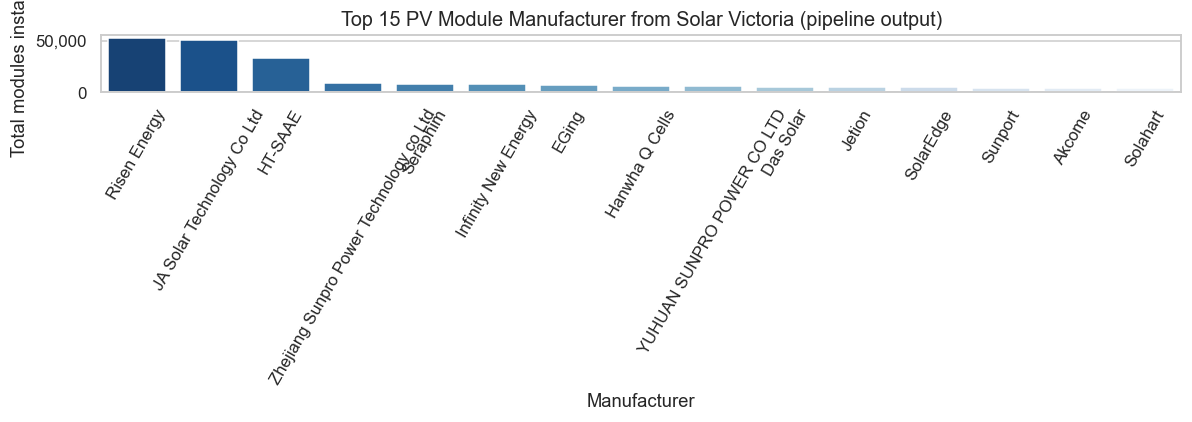

In [27]:
# --- Top 15 PV module manufacturers ---
pv = pm[pm['product_type'] == 'pv_module'].copy()
top_pv_brands = (
    pv.groupby('manufacturer')['count'].sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
top_pv_brands.columns = ['manufacturer', 'total']

fig, ax = plt.subplots(figsize=(11, 4))
sns.barplot(data=top_pv_brands, x='manufacturer', y='total', ax=ax, palette='Blues_r')
ax.set_title('Top 15 PV Module Manufacturer from Solar Victoria (pipeline output)', fontsize=13)
ax.set_xlabel('Manufacturer')
ax.set_ylabel('Total modules installed')
ax.tick_params(axis='x', rotation=60)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

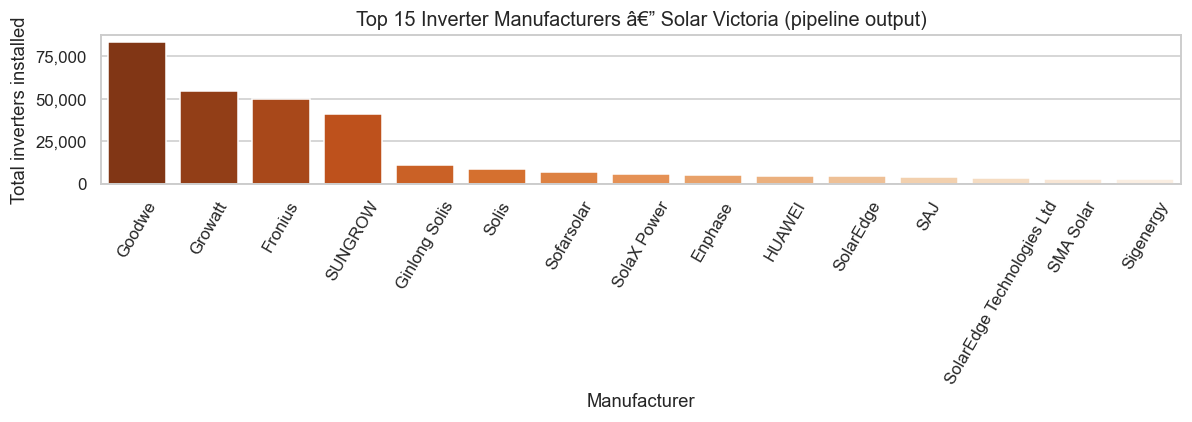

In [26]:
# --- Top 15 inverter manufacturers ---
inv = pm[pm['product_type'] == 'inverter'].copy()
top_inv_brands = (
    inv.groupby('manufacturer')['count'].sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
top_inv_brands.columns = ['manufacturer', 'total']

fig, ax = plt.subplots(figsize=(11, 4))
sns.barplot(data=top_inv_brands, x='manufacturer', y='total', ax=ax, palette='Oranges_r')
ax.set_title('Top 15 Inverter Manufacturers â€” Solar Victoria (pipeline output)', fontsize=13)
ax.set_xlabel('Manufacturer')
ax.set_ylabel('Total inverters installed')
ax.tick_params(axis='x', rotation=60)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

In the Solar Victoria program data, Jinko Solar and Canadian Solar account for the majority of PV module installs, while Fronius and SMA lead on inverters. Brand concentration is operationally useful: recycling contracts can be negotiated with a small number of manufacturers, and disassembly workflows only need to cover a handful of panel and inverter formats. The material stream is predictable.

---
## Summary

| Dataset | Key insight for SolarCycle |
|---|---|
|  | Demand is heavily concentrated — top postcodes dominate; efficient routing is feasible from day one |
|  | 664 facilities exist but none process solar panels; the infrastructure gap is documented |
|  | Jinko/Canadian Solar (panels) and Fronius/SMA (inverters) dominate; material stream is predictable |

**The pipeline confirms the pitch:** the demand clusters are real, the infrastructure gap is real, and the product mix is manageable.